# Setup (Libraries & Reproducibility)

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
import torch
from torch import nn, optim
import yfinance as yf
import random, os

SEED = 42
os.environ["PYTHONHASHSEED"]=str(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Download Close Prices

In [3]:
tickers = ["AAPL","MSFT","NVDA"]  # example
raw = yf.download(tickers, period="10y", interval="1d", auto_adjust=False)
close = raw["Close"].dropna(how="all").ffill().dropna(how="any")  # Close only
close.head()

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,MSFT,NVDA
Date,,,
2015-12-18,26.507500,54.130001,0.80350
2015-12-21,26.832500,54.830002,0.82250
2015-12-22,26.807501,55.349998,0.82325
2015-12-23,27.152500,55.820000,0.82650
2015-12-24,27.007500,55.669998,0.82925


# Baseline EDA: Returns & Volatility

In [4]:
# Log returns from Close
rets = np.log(close / close.shift(1)).dropna()
# Rolling volatility (20d)
vol20 = rets.rolling(20).std()

# Feature Engineering

In [5]:
win = 20
mu = rets.rolling(win).mean()
sigma = rets.rolling(win).std()
z = (rets - mu) / (sigma + 1e-9)

run_max = close.cummax()
dd = close / run_max - 1.0

# Build a Modeling Frame

In [6]:
def make_frame(close: pd.DataFrame, win:int=20):
    rets = np.log(close/close.shift(1))
    mu = rets.rolling(win).mean()
    sigma = rets.rolling(win).std()
    z = (rets - mu) / (sigma + 1e-9)
    vol20 = rets.rolling(20).std()
    vol60 = rets.rolling(60).std()
    run_max = close.cummax()
    dd = close/run_max - 1.0
    # stack features
    feats = pd.concat({
        "ret": rets, "z": z, "vol20": vol20, "vol60": vol60, "dd": dd
    }, axis=1).dropna()
    return feats

X = make_frame(close)
X.head()

ret                             z                      \
Ticker          AAPL      MSFT      NVDA      AAPL      MSFT      NVDA   
Date                                                                     
2016-03-17 -0.001605  0.005688 -0.008495 -0.494609  0.213266 -0.809065   
2016-03-18  0.001134 -0.021637  0.029719 -0.295726 -1.399214  1.452172   
2016-03-21 -0.000094  0.006893  0.002953 -0.357266  0.353016 -0.045698   
2016-03-22  0.007619  0.003891 -0.001771  0.148985  0.077542 -0.338585   
2016-03-23 -0.005544 -0.001851  0.016989 -0.948090 -0.292570  0.832673   

               vol20                         vol60                      \
Ticker          AAPL      MSFT      NVDA      AAPL      MSFT      NVDA   
Date                                                                     
2016-03-17  0.012799  0.015828  0.015970  0.019402  0.018263  0.025052   
2016-03-18  0.012723  0.016597  0.016850  0.019336  0.018399  0.025164   
2016-03-21  0.012736  0.016309  0.015341  0.019336  0.018379  0.025166   
2016-03-22  0.011000  0.014764  0.015388  0.019289  0.018351  0.025163   
2016-03-23  0.011083  0.014798  0.015670  0.019289  0.018350  0.025252   

                  dd                      
Ticker          AAPL      MSFT      NVDA  
Date                                      
2016-03-17 -0.027037 -0.033422 -0.025534  
2016-03-18 -0.025933 -0.054111  0.000000  
2016-03-21 -0.026025 -0.047568  0.000000  
2016-03-22 -0.018576 -0.043855 -0.001769  
2016-03-23 -0.024002 -0.045623  0.000000

# Baseline Rule: Rolling Z-Score Thresholds

In [7]:
zabs = X["z"]                          # wide
z_long = zabs.stack()                  # (date, ticker) MultiIndex Series
thr_long = z_long.groupby(level=1).transform(lambda s: s.quantile(0.995))
rule_alert = (z_long.abs() > thr_long).astype(int).unstack()  # back to wide
rule_alert.columns.name = "ticker"

# Quick Visualization (Baseline)

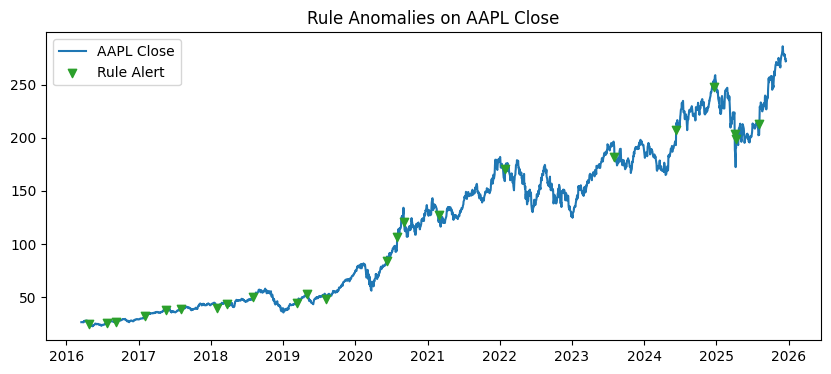

In [8]:
tkr = X["ret"].columns[0]

# Align dates from rule_alert to the price series
px = close[tkr].reindex(rule_alert.index)

# Select the chosen ticker's alert column (wide, not MultiIndex)
alerts = rule_alert[tkr].reindex(px.index).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(px.index, px.values, label=f"{tkr} Close", color="C0", zorder=1)

mask = alerts.eq(1)
ax.scatter(px.index[mask], px.values[mask], marker="v", s=36,
           color="C2", label="Rule Alert", zorder=4)

ax.set_title(f"Rule Anomalies on {tkr} Close")
ax.legend()
plt.show()

# Isolation Forest (Unsupervised)

In [9]:
# Prepare tabular features per ticker-date
feat_cols = ["ret","z","vol20","vol60","dd"]
def flatten_feats(X):
    # MultiIndex columns: (feature, ticker) -> wide table per date
    return (X.swaplevel(axis=1).sort_index(axis=1))  # (ticker,feature)

F = flatten_feats(X)
scaler = RobustScaler()
F_sc = pd.DataFrame(
    scaler.fit_transform(F), index=F.index, columns=F.columns
)

iso = IsolationForest(
    n_estimators=300, contamination=0.005, bootstrap=True, random_state=SEED
)
iso.fit(F_sc)
iso_score = -iso.decision_function(F_sc)  # higher = more anomalous
iso_alert = (iso_score > np.quantile(iso_score, 0.995)).astype(int)


# Visualise Isolation Forest Alerts

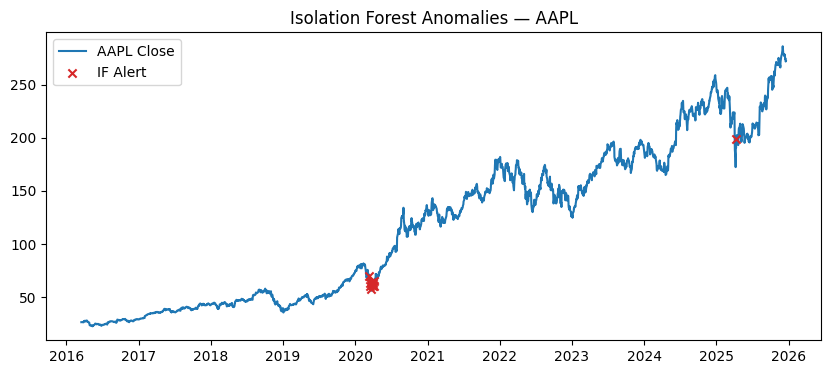

In [10]:
tkr = close.columns[0]
px = close[tkr].reindex(F.index)
ia = pd.Series(iso_alert, index=F.index)

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(px.index, px.values, label=f"{tkr} Close", color="C0", zorder=1)
ax.scatter(px.index[ia==1], px[ia==1], marker="x", s=35, color="C3",
           label="IF Alert", zorder=4)
ax.set_title(f"Isolation Forest Anomalies — {tkr}")
ax.legend()
plt.show()

# Make Windows from Close-Derived Returns

In [11]:
def make_windows(series: pd.Series, win=30, step=1):
    Xw, idx = [], []
    vals = series.dropna().values
    dates = series.dropna().index
    for i in range(0, len(vals)-win, step):
        Xw.append(vals[i:i+win])
        idx.append(dates[i+win-1])  # window end date
    return np.array(Xw, dtype=np.float32), pd.Index(idx, name="date")

tkr = close.columns[0]
rets_tkr = np.log(close[tkr]/close[tkr].shift(1))
Xw, idx = make_windows(rets_tkr, win=60, step=1)

scaler_w = RobustScaler()
Xw_sc = scaler_w.fit_transform(Xw)
Xw_sc = torch.tensor(Xw_sc, dtype=torch.float32)

# Autoencoder Architecture (PyTorch)

In [12]:
class AE(nn.Module):
    def __init__(self, D=60, bottleneck=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(D, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, bottleneck)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, D)
        )
    def forward(self, x): return self.decoder(self.encoder(x))

ae = AE(D=Xw_sc.shape[1], bottleneck=8)
opt = optim.Adam(ae.parameters(), lr=1e-3)
crit = nn.MSELoss()

# Train Autoencoder (No Look-Ahead)

In [13]:
# Use first 70% as "normal" training segment
n = len(Xw_sc)
n_tr = int(n*0.7)
Xtr = Xw_sc[:n_tr]

for epoch in range(25):
    ae.train(); opt.zero_grad()
    out = ae(Xtr)
    loss = crit(out, Xtr)
    loss.backward(); opt.step()

# Reconstruction Error & Threshold

In [14]:
ae.eval()
with torch.no_grad():
    recon = ae(Xw_sc).numpy()
err = ((recon - Xw_sc.numpy())**2).mean(axis=1)  # MSE per window
err_s = pd.Series(err, index=idx, name="ae_err")

# Pick a high percentile as alert threshold (e.g., 99th)
thr = err_s.quantile(0.99)
ae_alert = (err_s > thr).astype(int).rename("ae_alert")

# Plot Close vs AE Error

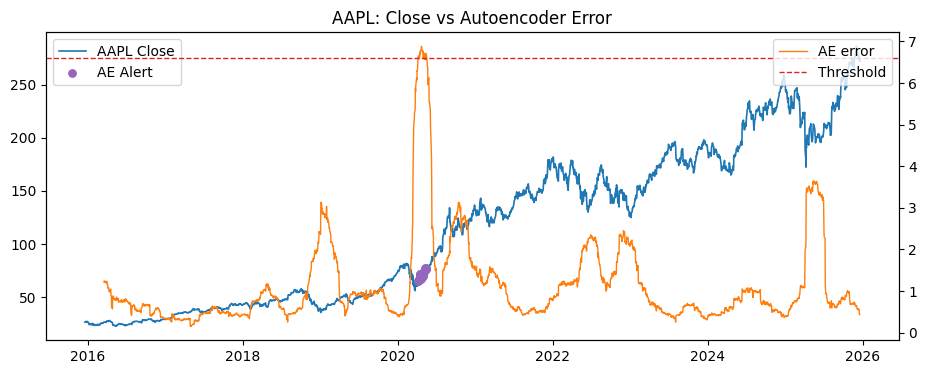

In [15]:
fig, ax1 = plt.subplots(figsize=(11,4))
ax1.plot(close[tkr].index, close[tkr].values, label=f"{tkr} Close", linewidth=1.2)

ax2 = ax1.twinx()
ax2.plot(err_s.index, err_s.values, label="AE error", linewidth=1.0, color="tab:orange")
ax2.axhline(thr, linestyle="--", linewidth=1.0, color="tab:red", label="Threshold")

# Mark alerts
alert_idx = err_s.index[ae_alert==1]
ax1.scatter(alert_idx, close[tkr].reindex(alert_idx), s=28, marker="o",
            color="tab:purple", label="AE Alert", zorder=3)

ax1.set_title(f"{tkr}: Close vs Autoencoder Error"); 
ax1.legend(loc="upper left"); ax2.legend(loc="upper right"); plt.show()